# Baseline Model — SARIMA
**Project:** Agri Price Forecast | **Author:** Your Name

This notebook:
1. Establishes the ARIMA/SARIMA baseline (existing govt approach)
2. Tests for stationarity (ADF test)
3. Selects optimal (p,d,q) parameters via AIC
4. Evaluates on test set: RMSE, MAE, MAPE
5. Saves metrics for comparison table

**This is the model we must beat with LSTM/TFT/XGBoost.**

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
import mlflow

from src.data.database import init_db
from src.models.evaluate import evaluate_all, rmse, mae, mape
from src.utils.config import MLFLOW_TRACKING_URI, MLFLOW_EXPERIMENT_NAME, TRAIN_RATIO, VAL_RATIO

init_db()
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT_NAME)
plt.style.use('seaborn-v0_8-whitegrid')
print('Setup complete')

2026-05-26 11:30:45 | INFO     | src.data.database | Database schema initialised at sqlite:///C:\Users\Jeya Devi\OneDrive\Desktop\dev-projects\agri-price-forecast\data\agri_prices.db
Setup complete


## 1. Load Feature Matrix

In [2]:
feat_df = pd.read_csv('../data/processed/features_onion.csv', parse_dates=['date'])
feat_df = feat_df.sort_values('date').reset_index(drop=True)

series = feat_df.set_index('date')['modal_price'].asfreq('D').ffill()

train_val = series[series.index < '2024-01-01']
test      = series[series.index >= '2024-01-01']
n_tv      = len(train_val)
n_val     = int(n_tv * 0.15)
train     = train_val.iloc[:-n_val]
val       = train_val.iloc[-n_val:]

print(f"Train: {len(train)} | Val: {len(val)} | Test: {len(test)}")
print(f"Train: {train.index.min().date()} to {train.index.max().date()}")
print(f"Test:  {test.index.min().date()} to {test.index.max().date()}")

Train: 7080 | Val: 1249 | Test: 705
Train: 2001-03-13 to 2020-07-30
Test:  2024-01-01 to 2025-12-05


## 2. Stationarity Tests

In [3]:
def adf_test(series, title=''):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'--- ADF Test: {title} ---')
    print(f'ADF Statistic:  {result[0]:.4f}')
    print(f'p-value:        {result[1]:.4f}')
    print(f'Critical (5%):  {result[4]["5%"]:.4f}')
    stationary = result[1] < 0.05
    print(f'Stationary:     {stationary} ({"REJECT H0" if stationary else "FAIL TO REJECT H0"})')
    print()
    return stationary

# Test original series
is_stationary = adf_test(series, 'Original Series')

# Test first difference
diff1 = series.diff().dropna()
is_stationary_d1 = adf_test(diff1, 'First Difference')

# Test second difference if needed
if not is_stationary_d1:
    diff2 = diff1.diff().dropna()
    adf_test(diff2, 'Second Difference')

d = 0 if is_stationary else 1
print(f'=> Using d={d} for ARIMA')

--- ADF Test: Original Series ---
ADF Statistic:  -6.0145
p-value:        0.0000
Critical (5%):  -2.8619
Stationary:     True (REJECT H0)

--- ADF Test: First Difference ---
ADF Statistic:  -12.1343
p-value:        0.0000
Critical (5%):  -2.8619
Stationary:     True (REJECT H0)

=> Using d=0 for ARIMA


## 3. ACF / PACF Plots (p and q selection)

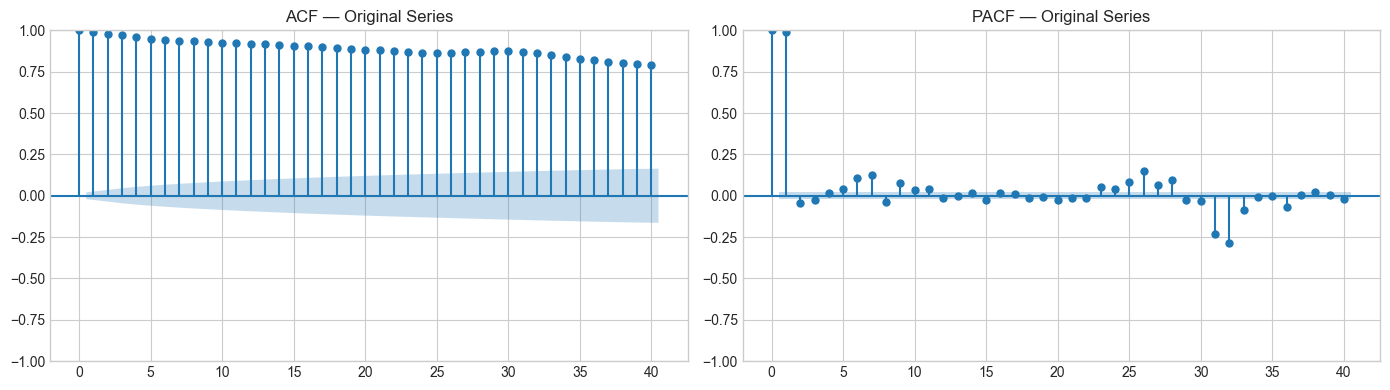

ACF → MA order (q): significant lags after cut-off
PACF → AR order (p): significant lags after cut-off


In [4]:
series_to_plot = diff1 if d == 1 else series

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(series_to_plot.dropna(), lags=40, ax=axes[0], alpha=0.05)
axes[0].set_title(f'ACF — {"First Differenced" if d==1 else "Original"} Series')
plot_pacf(series_to_plot.dropna(), lags=40, ax=axes[1], alpha=0.05, method='ywm')
axes[1].set_title(f'PACF — {"First Differenced" if d==1 else "Original"} Series')
plt.tight_layout()
plt.savefig('../docs/arima_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()
print('ACF → MA order (q): significant lags after cut-off')
print('PACF → AR order (p): significant lags after cut-off')

## 4. Train / Val / Test Split

Train: 6956 | Val: 1739 | Test: 339
Train: 6956 rows (2001-03-13 to 2020-03-28)
Val:   1739 rows (2020-03-29 to 2024-12-31)
Test:  339 rows (2025-01-01 to 2025-12-05)


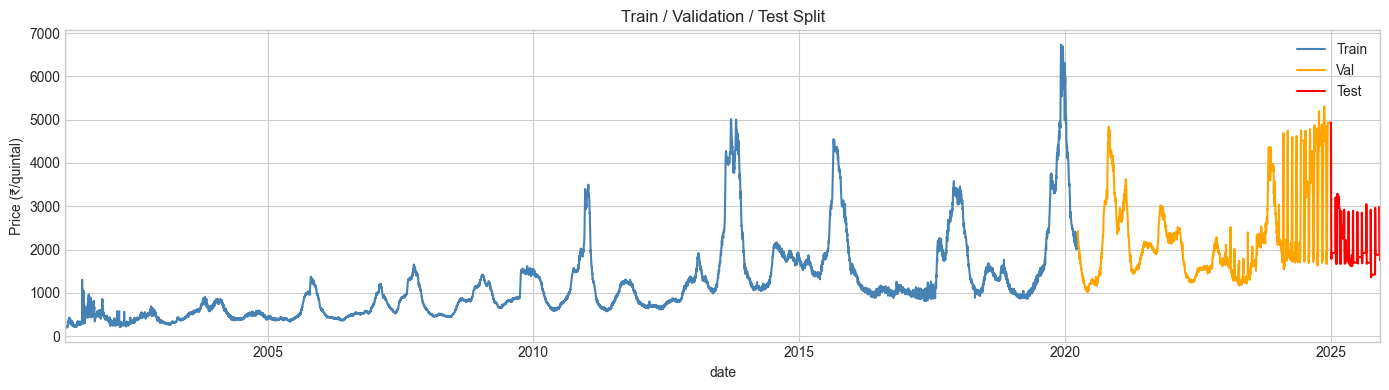

In [5]:
train_val = series[series.index < '2025-01-01']
test      = series[series.index >= '2025-01-01']
n_tv  = len(train_val)
n_val = int(n_tv * 0.20)
train = train_val.iloc[:-n_val]
val   = train_val.iloc[-n_val:]

print(f"Train: {len(train)} | Val: {len(val)} | Test: {len(test)}")

print(f'Train: {len(train)} rows ({train.index.min().date()} to {train.index.max().date()})')
print(f'Val:   {len(val)} rows ({val.index.min().date()} to {val.index.max().date()})')
print(f'Test:  {len(test)} rows ({test.index.min().date()} to {test.index.max().date()})')

fig, ax = plt.subplots(figsize=(14, 4))
train.plot(ax=ax, label='Train', color='steelblue')
val.plot(ax=ax, label='Val', color='orange')
test.plot(ax=ax, label='Test', color='red')
ax.legend()
ax.set_title('Train / Validation / Test Split')
ax.set_ylabel('Price (₹/quintal)')
plt.tight_layout()
plt.show()

## 5. Fit SARIMA Model

In [6]:
# SARIMA(p,d,q)(P,D,Q,s)
# p=1 (AR), d=1 (differencing), q=1 (MA)
# Seasonal: P=1, D=1, Q=1, s=7 (weekly)
ORDER          = (1, 1, 1)
SEASONAL_ORDER = (1, 1, 1, 7)

print(f'Fitting SARIMA{ORDER}x{SEASONAL_ORDER}...')
print('This may take 1-2 minutes...')

with mlflow.start_run(run_name='SARIMA_baseline'):
    model = SARIMAX(
        train,
        order=ORDER,
        seasonal_order=SEASONAL_ORDER,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    fit = model.fit(disp=False)
    print(fit.summary())

    # Log to MLflow
    mlflow.log_params({'order': str(ORDER), 'seasonal_order': str(SEASONAL_ORDER)})
    mlflow.log_metric('aic', fit.aic)
    mlflow.log_metric('bic', fit.bic)

print(f'\nAIC: {fit.aic:.2f} | BIC: {fit.bic:.2f}')

Fitting SARIMA(1, 1, 1)x(1, 1, 1, 7)...
This may take 1-2 minutes...
                                     SARIMAX Results                                     
Dep. Variable:                       modal_price   No. Observations:                 6956
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood              -38231.671
Date:                           Tue, 26 May 2026   AIC                          76473.341
Time:                                   11:30:51   BIC                          76507.566
Sample:                               03-13-2001   HQIC                         76485.140
                                    - 03-28-2020                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3600      0.014    -26.365      0.00

## 6. Residual Diagnostics

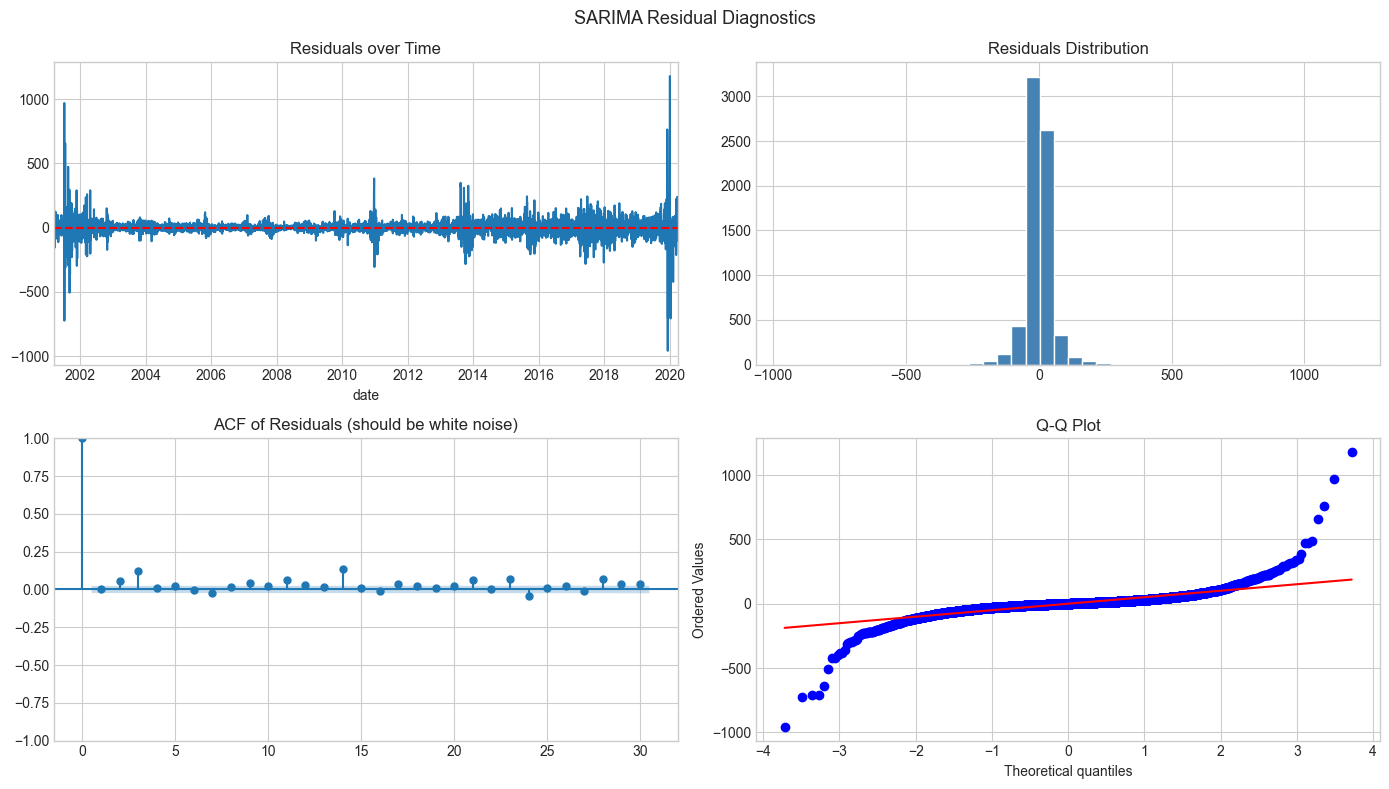

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
residuals = fit.resid

residuals.plot(ax=axes[0,0], title='Residuals over Time')
axes[0,0].axhline(0, color='red', linestyle='--')

axes[0,1].hist(residuals, bins=40, color='steelblue', edgecolor='white')
axes[0,1].set_title('Residuals Distribution')

plot_acf(residuals, lags=30, ax=axes[1,0])
axes[1,0].set_title('ACF of Residuals (should be white noise)')

from scipy import stats
stats.probplot(residuals, plot=axes[1,1])
axes[1,1].set_title('Q-Q Plot')

plt.suptitle('SARIMA Residual Diagnostics', fontsize=13)
plt.tight_layout()
plt.savefig('../docs/arima_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Forecast on Test Set

In [8]:
# Rolling one-step-ahead forecast on test set (realistic evaluation)
history = list(train) + list(val)
predictions = []
actuals = list(test)

print(f'Running rolling forecast on {len(test)} test points...')
for i in range(len(test)):
    model_tmp = SARIMAX(
        history,
        order=ORDER,
        seasonal_order=SEASONAL_ORDER,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    fit_tmp = model_tmp.fit(disp=False, start_params=fit.params)
    yhat = fit_tmp.forecast(steps=1)[0]
    predictions.append(yhat)
    history.append(actuals[i])
    if (i+1) % 10 == 0:
        print(f'  {i+1}/{len(test)} done')

predictions = np.array(predictions)
actuals_arr = np.array(actuals)

print('Rolling forecast complete.')

Running rolling forecast on 339 test points...


c:\Users\Jeya Devi\OneDrive\Desktop\dev-projects\agri-price-forecast\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Jeya Devi\OneDrive\Desktop\dev-projects\agri-price-forecast\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Jeya Devi\OneDrive\Desktop\dev-projects\agri-price-forecast\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Jeya Devi\OneDrive\Desktop\dev-projects\agri-price-forecast\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization

  10/339 done


c:\Users\Jeya Devi\OneDrive\Desktop\dev-projects\agri-price-forecast\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Jeya Devi\OneDrive\Desktop\dev-projects\agri-price-forecast\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Jeya Devi\OneDrive\Desktop\dev-projects\agri-price-forecast\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  20/339 done
  30/339 done


...

  320/339 done


c:\Users\Jeya Devi\OneDrive\Desktop\dev-projects\agri-price-forecast\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Jeya Devi\OneDrive\Desktop\dev-projects\agri-price-forecast\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Jeya Devi\OneDrive\Desktop\dev-projects\agri-price-forecast\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  330/339 done


c:\Users\Jeya Devi\OneDrive\Desktop\dev-projects\agri-price-forecast\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Jeya Devi\OneDrive\Desktop\dev-projects\agri-price-forecast\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Jeya Devi\OneDrive\Desktop\dev-projects\agri-price-forecast\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Jeya Devi\OneDrive\Desktop\dev-projects\agri-price-forecast\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization

Rolling forecast complete.


## 8. Evaluate and Save Metrics

In [9]:
metrics = evaluate_all(actuals_arr, predictions, model_name='SARIMA')
print('\n=== SARIMA BASELINE METRICS ===')
for k, v in metrics.items():
    if k != 'model':
        print(f'{k.upper()}: {v:.4f}')

# Log to MLflow
with mlflow.start_run(run_name='SARIMA_baseline_eval'):
    mlflow.log_metrics({k: v for k, v in metrics.items() if k != 'model'})

# Save metrics JSON for comparison notebook
import json
with open('../docs/metrics_sarima.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print('\nMetrics saved to docs/metrics_sarima.json')

2026-05-26 12:16:28 | INFO     | src.models.evaluate | [SARIMA] RMSE=304.71 | MAE=128.47 | MAPE=5.76% | SMAPE=5.73% | R2=0.6043

=== SARIMA BASELINE METRICS ===
RMSE: 304.7103
MAE: 128.4709
MAPE: 5.7600
SMAPE: 5.7276
R2: 0.6043

Metrics saved to docs/metrics_sarima.json


## 9. Forecast Plot

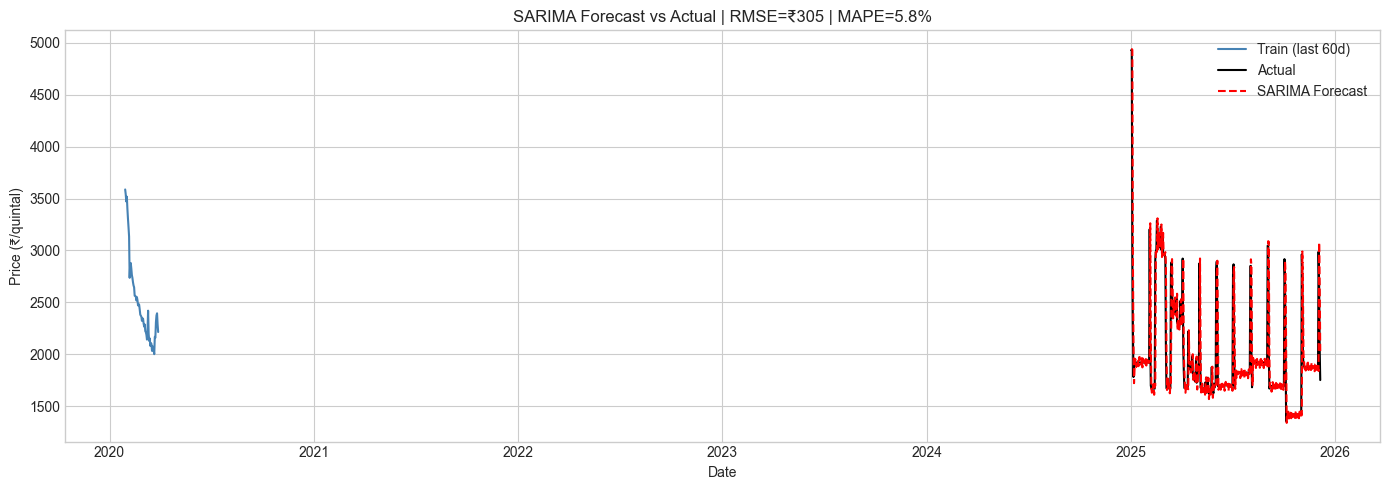


Baseline set:
  RMSE = ₹304.71/quintal
  MAE  = ₹128.47/quintal
  MAPE = 5.76%
  R²   = 0.6043

=> Any model beating these numbers is a contribution to the paper.


In [10]:
fig, ax = plt.subplots(figsize=(14, 5))

# Show last 60 days of train + full test
ax.plot(train.index[-60:], train.values[-60:], color='steelblue', label='Train (last 60d)', linewidth=1.5)
ax.plot(test.index, actuals_arr, color='black', label='Actual', linewidth=1.5)
ax.plot(test.index, predictions, color='red', linestyle='--', label='SARIMA Forecast', linewidth=1.5)

ax.set_title(f'SARIMA Forecast vs Actual | RMSE=₹{metrics["rmse"]:.0f} | MAPE={metrics["mape"]:.1f}%')
ax.set_ylabel('Price (₹/quintal)')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.savefig('../docs/arima_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nBaseline set:')
print(f'  RMSE = ₹{metrics["rmse"]:.2f}/quintal')
print(f'  MAE  = ₹{metrics["mae"]:.2f}/quintal')
print(f'  MAPE = {metrics["mape"]:.2f}%')
print(f'  R²   = {metrics["r2"]:.4f}')
print(f'\n=> Any model beating these numbers is a contribution to the paper.')

## 10. Multi-step Forecast (7-day horizon)
This is the actual use case — predict 7 days ahead for market intervention decisions.

c:\Users\Jeya Devi\OneDrive\Desktop\dev-projects\agri-price-forecast\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


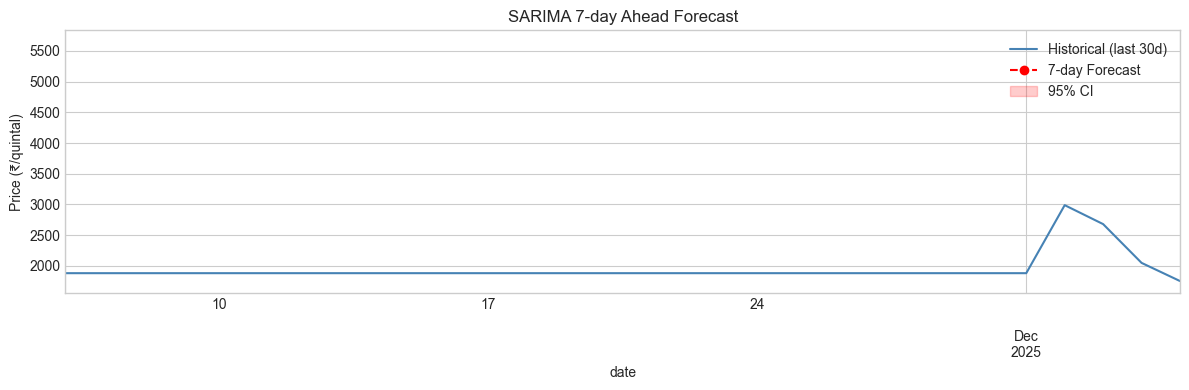

7-day SARIMA Forecast:
  2025-12-06: ₹4977/quintal
  2025-12-07: ₹4991/quintal
  2025-12-08: ₹5008/quintal
  2025-12-09: ₹5008/quintal
  2025-12-10: ₹5007/quintal
  2025-12-11: ₹5012/quintal
  2025-12-12: ₹4968/quintal


In [11]:
# Fit on train+val, forecast next 7 days
full_train = pd.concat([train, val])
model_final = SARIMAX(
    full_train,
    order=ORDER,
    seasonal_order=SEASONAL_ORDER,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
fit_final = model_final.fit(disp=False)
forecast_7d = fit_final.forecast(steps=7)
conf_int = fit_final.get_forecast(steps=7).conf_int()

future_dates = pd.date_range(series.index[-1] + pd.Timedelta(days=1), periods=7)

fig, ax = plt.subplots(figsize=(12, 4))
series.iloc[-30:].plot(ax=ax, color='steelblue', label='Historical (last 30d)')
ax.plot(future_dates, forecast_7d.values, 'r--o', label='7-day Forecast')
ax.fill_between(future_dates, conf_int.iloc[:,0], conf_int.iloc[:,1], alpha=0.2, color='red', label='95% CI')
ax.set_title('SARIMA 7-day Ahead Forecast')
ax.set_ylabel('Price (₹/quintal)')
ax.legend()
plt.tight_layout()
plt.savefig('../docs/arima_7day_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

print('7-day SARIMA Forecast:')
for d, p in zip(future_dates, forecast_7d.values):
    print(f'  {d.date()}: ₹{p:.0f}/quintal')